In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy as spy
from sklearn.neighbors import KernelDensity
from statsmodels.nonparametric.smoothers_lowess import lowess
import seaborn as sns

In [4]:
#import local packages
from DPosIT import DPosIT
from em_nuc_model import EMNucModel
from exo_model import ExoModel

/home/d_ryabov/.conda/envs/NucDPosIT/lib/python3.6/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
# MNASE1 = "data/reads/MNase_1/mapping/mnase_99_147_nodup.sam"
exo_sam = "/home/d_ryabov/MiSeq/scripts/data/reads/MNase-Exo_less2/SRR1802184_99_147_nodup.sam"

/home/d_ryabov/MiSeq/NucDPosIT/src/NucDPosIT/Alignment_file_manager.py:71: UserWarning: found BAM file
  warnings.warn("found BAM file")
/home/d_ryabov/MiSeq/NucDPosIT/src/NucDPosIT/Alignment_file_manager.py:80: UserWarning: index found
  warnings.warn("index found")


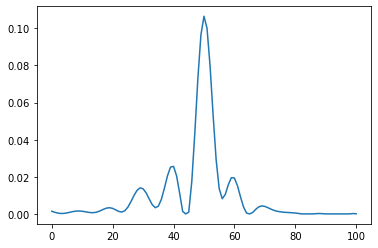

In [6]:
dpst = DPosIT(exo_sam, 'sam', 'tmp', reg_koef=0.18, max_iter=1000)
dpst.fit_exo('model_data/exo_probs.csv')
plt.plot(dpst.fit_res)

In [7]:
N = 50000
kde = KernelDensity()

digested_nucs = dpst.digest_nucs(N)

In [8]:
pos = np.array(list(map(lambda x: [x.start, x.end], digested_nucs)))
kde.fit(pos)

KernelDensity()

In [10]:
chromosomes = dpst.file_manager.chromosomes
chromosomes

('NC_001133.9',
 'NC_001134.8',
 'NC_001135.5',
 'NC_001136.10',
 'NC_001137.3',
 'NC_001138.5',
 'NC_001139.9',
 'NC_001140.6',
 'NC_001141.2',
 'NC_001142.9',
 'NC_001143.9',
 'NC_001144.5',
 'NC_001145.3',
 'NC_001146.8',
 'NC_001147.6',
 'NC_001148.4',
 'NC_001224.1')

100%|██████████| 500/500 [00:02<00:00, 192.53it/s]


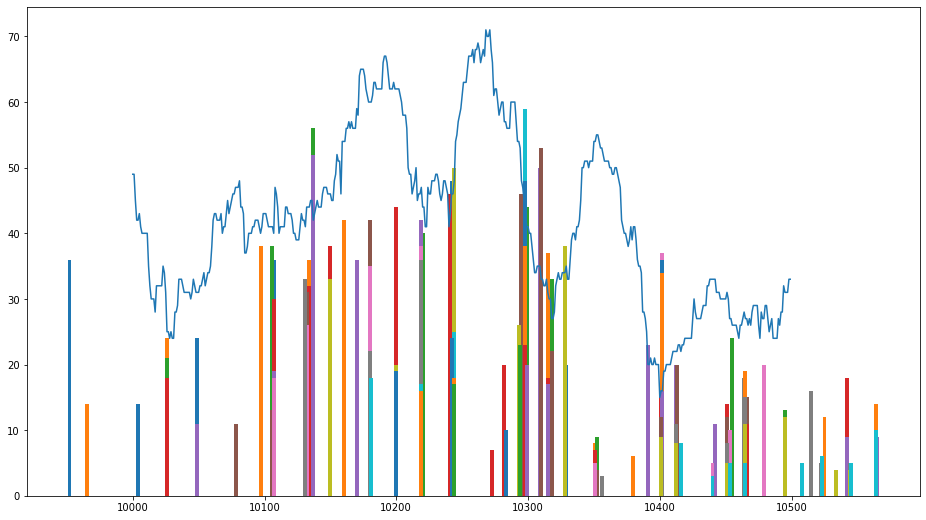

In [237]:
n_nucs = 10
winlen = 300
start = 10000
stop = 10500
chromosome = 'NC_001133.9'

model = EMNucModel(n_nucs, 'ADDSEM', dpst.fit_res, max_iter=500)

coverage = np.array(dpst.alignemnt.count_coverage(chromosome, start, stop)).sum(0)

plt.figure(figsize=(16, 9))
plt.plot(np.arange(start, stop), coverage)
df = pd.DataFrame()


for i, batch in enumerate(dpst.iterover(chromosome, iterover='overlap', win_len=winlen, start=start, stop=stop, step=25)):
    # print(batch)
    model.fit(batch)
    w_opt, theta_opt = model.weights_, model.positions_
    cluster_occ = model.cluster_occupancy()
    plt.bar(theta_opt, cluster_occ, 3)
    
    window_data = pd.DataFrame(batch, columns=['start', 'stop'])
    window_data['mid'] = (window_data.start + window_data.stop) / 2

    prob_matrix = model.predict_matrix(batch)
    nuc_indxex = np.argmax(prob_matrix, axis=0)
    window_data["dyad"] = theta_opt[nuc_indxex]
    window_data["nuc_prob"] = w_opt[nuc_indxex]
    window_data["prob"] = np.max(prob_matrix, axis=0)
    window_data['i'] = i
    df = pd.concat([df, window_data])
    
df.reset_index(drop=True, inplace=True)

In [207]:
theta_opt

array([10401, 10564, 10465, 10545, 10495, 10325, 10451, 10412, 10325,
       10523])

In [238]:
df

,start,stop,mid,dyad,nuc_prob,prob,i
0,9858,10002,9930.0,9952,0.105740,1.000000,0
1,9878,10002,9940.0,9952,0.105740,1.000000,0
2,9876,10002,9939.0,9952,0.105740,1.000000,0
3,9854,10002,9928.0,9952,0.105740,1.000000,0
4,9855,10002,9928.5,9952,0.105740,1.000000,0
...,...,...,...,...,...,...,...
4363,10494,10645,10569.5,10564,0.212766,0.992341,19
4364,10494,10639,10566.5,10564,0.212766,0.993965,19
4365,10494,10629,10561.5,10564,0.212766,0.836073,19
4366,10498,10565,10531.5,10523,0.148936,1.000000,19


In [210]:
group_size = df.groupby(['i', "dyad"]).size().reset_index()
group_size.name = 'size'
group_size.rename(columns={0: 'size'}, inplace=True)
# group_size.plot.bar()
# _ = plt.xticks(np.arange(len(theta_opt)), labels=theta_opt)

In [228]:
df['stat'] = df.dyad - df.mid
df['stat'] = df.groupby('dyad', group_keys=False).stat.apply(lambda x: x  / x.std() )
df['stat'] = df['stat'] ** 2
norm1 = df.groupby('dyad').stat.agg(sum)
norm1.name = 'stat'
statistics = pd.merge(norm1, group_size, on='dyad').reset_index(drop=True)
p_values = [1 - spy.stats.chi2.cdf(row.stat, row['size']) for i, row in statistics.iterrows()]
statistics['p_vals'] = p_values

In [230]:
statistics

,dyad,stat,i,size,p_vals
0,9930,46.819964,0,23,2.361799e-03
1,9962,14.751867,0,15,4.694340e-01
2,9965,13.008232,1,14,5.258755e-01
3,10026,81.600575,0,32,3.269183e-06
4,10026,81.600575,1,24,3.375358e-08
...,...,...,...,...,...
189,10564,71.928662,18,10,1.878375e-11
190,10564,71.928662,19,10,1.878375e-11
191,10565,36.885764,10,10,5.922707e-05
192,10565,36.885764,13,9,2.758265e-05


In [14]:
model.model.M_step()
ms = model.model.gij.T @ model.model.m
''

plt.imshow(ms, aspect=50)

ValueError: matmul: Input operand 1 does not have enough dimensions (has 0, gufunc core with signature (n?,k),(k,m?)->(n?,m?) requires 1)

In [105]:
np.all(model.model.gij == 0, axis=1)

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False,  True])

In [117]:
spy.stats.multinomial.rvs(1, [0, 0, ])

array([0, 0, 1])